<a href="https://colab.research.google.com/github/kiaraspreckley/KiaraSpreckley_DataScience_GenAI_Submission/blob/main/EDA_Titanic_Data_Set_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 I need to start by loading the data, I am going to use genai with the query

“please create a data frame from “EDA-DP.csv”


In [ ]:
import pandas as pd

df = pd.read_csv("EDA-DP.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


The data frame seems to have worked, I will now check if there is any missing data. I have copied this code from the GitHub "2_05_Exploratory_Data_Analysis.ipynb"

In [ ]:
df.isnull().sum()


,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


There is no missing data! Thats good, I will now check the desciptive statistics, I have copied this code from the GitHub "2_05_Exploratory_Data_Analysis.ipynb"

In [ ]:
df.describe()


,work_year,salary,salary_in_usd,remote_ratio
count,16534.000000,1.653400e+04,16534.000000,16534.000000
mean,2023.226866,1.637270e+05,149686.777973,32.003750
std,0.713558,3.402057e+05,68505.293156,46.245158
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.017630e+05,101125.000000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.872000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


The work year column tells me the range of this data is from 2020-2024, being a 4 year time period. By comparing the Max in the Salary and Salary in USD column, there is clearly a large difference between the two, I can therefore conclude it would be better to use the "salary in USD" variable when comparing variables in relation to salary as this measure is standardised.

The remote ratio range from 100 to 0 makes sense, however the mean of 32% stands out as this means that on average, employees in the data set work aproximatley 1/3 of the time remotley, I would have assumed this average to be lower.


I will compare the average salary in USD, I will use the AI prompt "can you compare company size with the average salary in usd". I expect that in a bigger company the average salary will be higher.

In [ ]:
df.groupby('company_size')['salary_in_usd'].mean().sort_values(ascending=False)

,salary_in_usd
company_size,
M,151059.071214
L,140889.563462
S,86627.111702


From this, I can tell that the average salary in USD is highest when in a medium sized company, to better see the scale of this difference, I will ask AI to present this in a Bar chart, using the prompt "Compare the company size with average salary in USD in a bar chart"

/tmp/ipython-input-772098608.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary_by_company_size.index, y=avg_salary_by_company_size.values, palette='viridis')


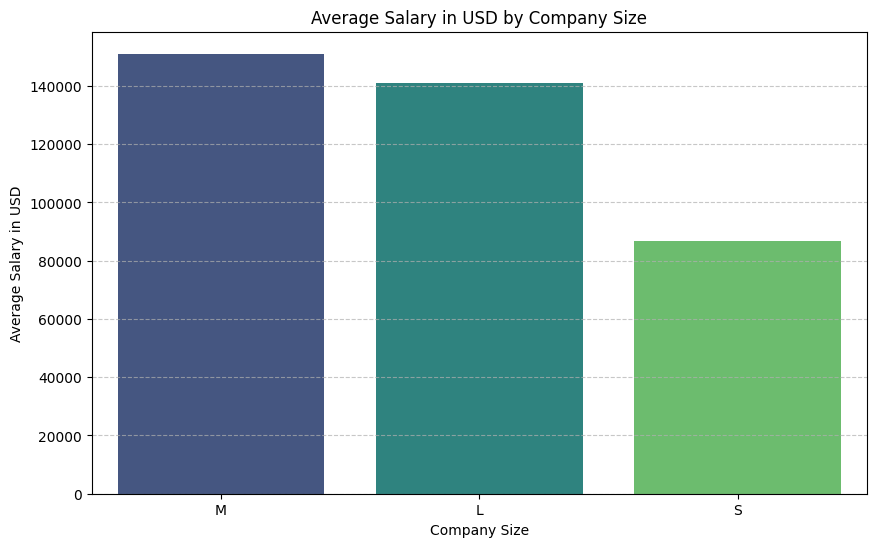

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average salary in USD for each company size
avg_salary_by_company_size = df.groupby('company_size')['salary_in_usd'].mean().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_salary_by_company_size.index, y=avg_salary_by_company_size.values, palette='viridis')
plt.title('Average Salary in USD by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Average Salary in USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This is interesting as it shows that in a medium company, average salary is slightly higher than in a large company. I will now check how many entries there are for each of the "L" "M" and "S" company size. I will use the AI prompt "show how many entries there are in total for each different company size"


In [ ]:
df['company_size'].value_counts()

,count
company_size,
M,15306
L,1040
S,188


This shows that there is significantly more salary data from Medium companies, therefore to conclude with more confidence the relationship between salaries from different company sizes, we would want to have more data in Large and Small companies.

I will now compare the job title to the average salary in USD, I will use the AI prompt "Compare the average salary in USD to the job type in a bar graph" I would expect job types with leadership or manager positions will have a higher salary.

/tmp/ipython-input-1374674150.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary_by_job_title.values, y=avg_salary_by_job_title.index, palette='viridis')


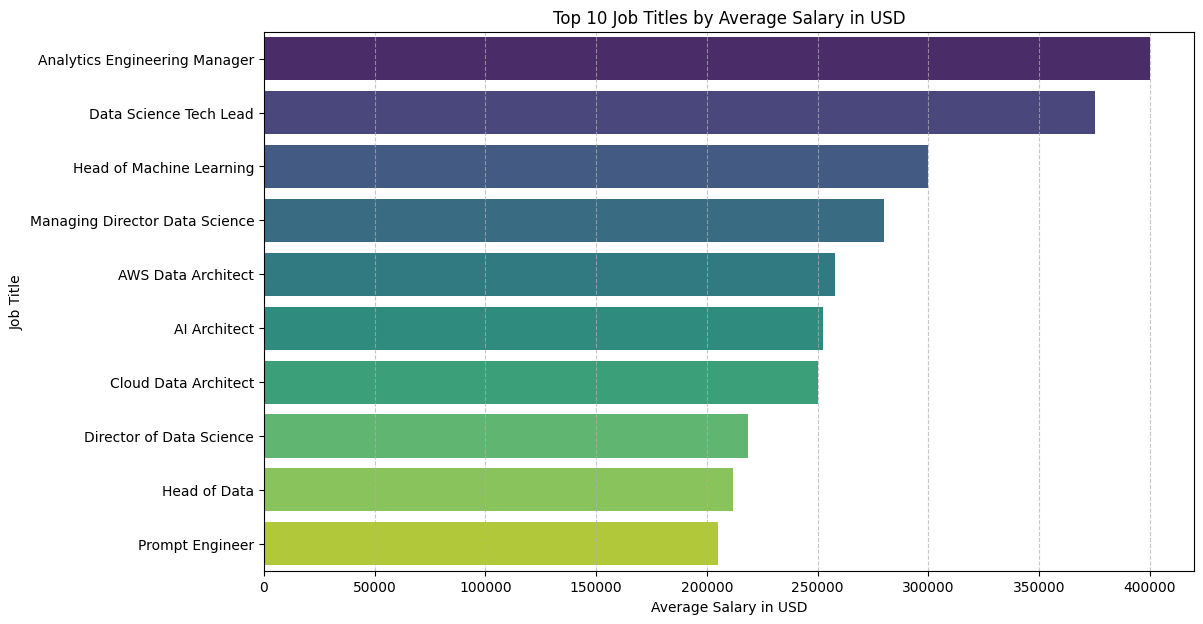

In [ ]:
# Calculate the average salary in USD for each job title and get the top 10
avg_salary_by_job_title = df.groupby('job_title')['salary_in_usd'].mean().nlargest(10)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_salary_by_job_title.values, y=avg_salary_by_job_title.index, palette='viridis')
plt.title('Top 10 Job Titles by Average Salary in USD')
plt.xlabel('Average Salary in USD')
plt.ylabel('Job Title')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

It seems like the job title has a significant influence on average salary in USD, this is to be expected as salaries typically increase with promotions.

I will now compare how salary in USD changed over different years, I will use the AI Prompt "Create a scatter plot showing salary in USD compared to the work year"

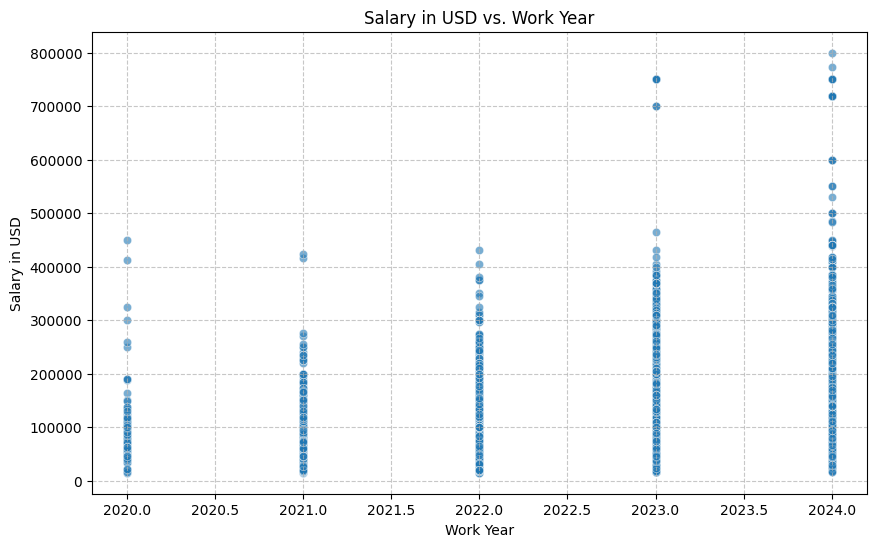

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='work_year', y='salary_in_usd', data=df, alpha=0.6)
plt.title('Salary in USD vs. Work Year')
plt.xlabel('Work Year')
plt.ylabel('Salary in USD')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This shows a slight trend of salary in USD seemingly increasing in later years, to check this better i will take the average salary in USD in each of these years. I will use the AI prompt "Create a scatter plot showing AVERAGE salary in USD compared to the work year"

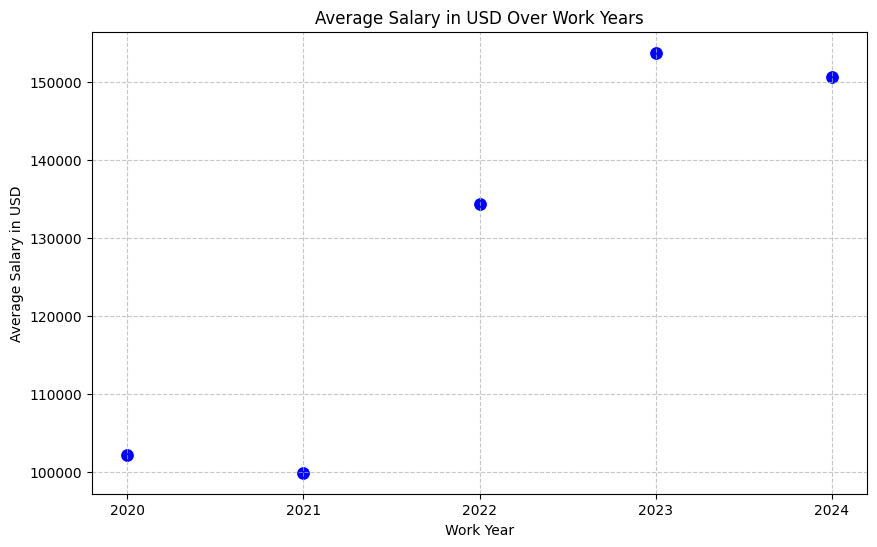

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average salary in USD for each work year
avg_salary_by_year = df.groupby('work_year')['salary_in_usd'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='work_year', y='salary_in_usd', data=avg_salary_by_year, s=100, color='blue')
plt.title('Average Salary in USD Over Work Years')
plt.xlabel('Work Year')
plt.ylabel('Average Salary in USD')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(avg_salary_by_year['work_year'].unique()) # Ensure all years are shown as ticks
plt.show()

From this, I can see there actually is not an clear linear increasing trend of higher salaries in more recent years, although, the fact that 2020 and 2021 have significantly lower average salaries could be due to COVID-19, therefore if I was investigating this data further and wanting to draw significant conclusions, I may consider how COVID-19 could be impacting other calculated averages

I will now create a histogram to visualse the distribution of salary in USD. I am copying the code from the GitHub "2_05_Exploratory_Data_Analysis.ipynb"

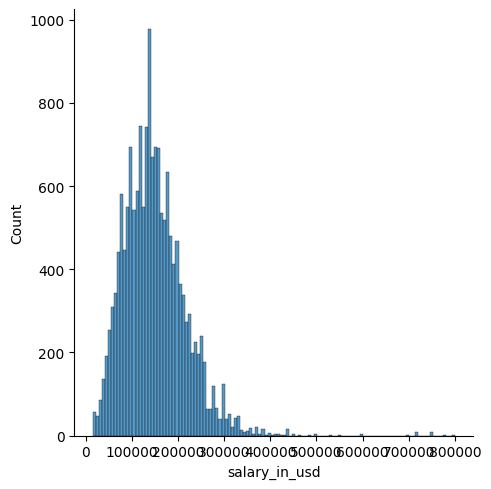

In [ ]:
ax = sns.displot(df['salary_in_usd'])


This histogram shows a bell curve, the distribution of salaries in USD is right-skewed. This means that the majority of the salaries are concentrated at the lower end of the range, and there is fewer, much higher salaries extending to the right. The histogram shows that while the typical salary is likely in the $100,000  to $200,000 range, the average salary would probably be higher than this peak due to the influence of the few very high salaries in the long right tail.

I will now create a count plot to see the distribution of the "remote ratio" category. I will use the prompt "create a count plot to show the distribution of the remote ratio category"

/tmp/ipython-input-3041384003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='remote_ratio', data=df, palette='viridis')


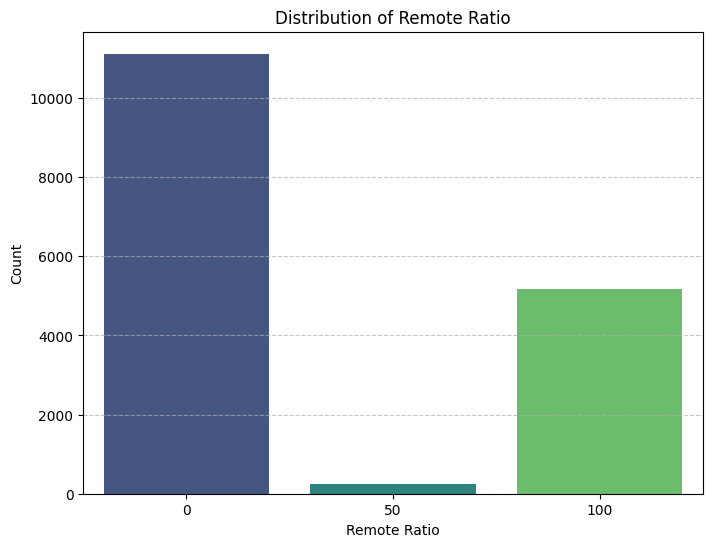

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='remote_ratio', data=df, palette='viridis')
plt.title('Distribution of Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This shows that the majority of roles are fully on-site followed by a significant number of fully remote positions, while hybrid roles are remarkably rare. I will now see if the remote ratio influences salary earnings, I will use the AI prompt "create a box plot to show the distribution of salary in usd against the remote ratio"

/tmp/ipython-input-1148570652.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df, palette='viridis')


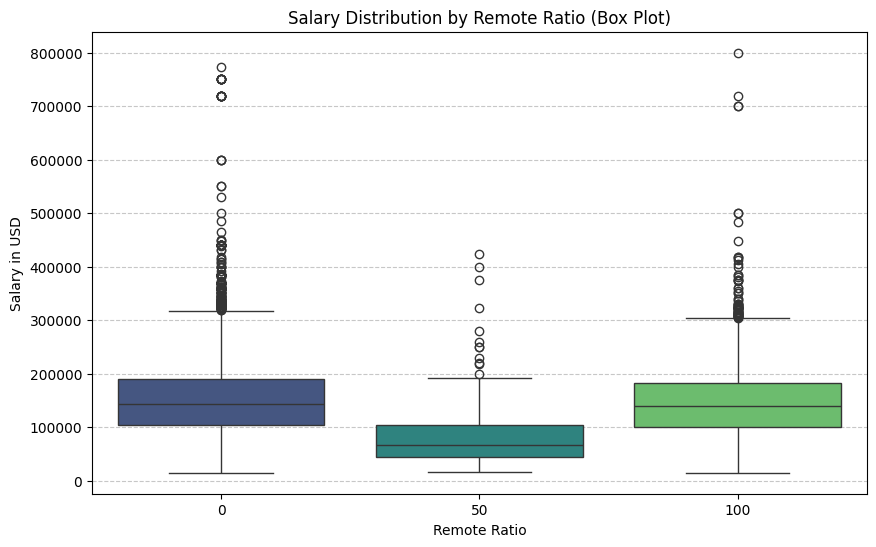

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df, palette='viridis')
plt.title('Salary Distribution by Remote Ratio (Box Plot)')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary in USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From this, I can see that on-site jobs generally offer higher salaries and a wider range of high-paying opportunities. Hybrid jobs seem to pay the least, but fully remote roles, while having a slightly lower typical salary than on-site, can still reach very high incomes, suggesting that top talent can earn well regardless of location.

Understanding the distribution of the experince level is important because if there are a higher majority of expericed roles in this data set, it may be skweing the average to be higher, if it is not proportionatlayy acurate of the data sample. I will use the ai prompt "Show the count of each experince level"

In [ ]:
df['experience_level'].value_counts()

,count
experience_level,
SE,10670
MI,4038
EN,1325
EX,501


The dataset is heavily skewed towards Senior-level professionals, which represent the largest group with 10,670 entries. Mid-level professionals are the second largest group, followed by Entry-level, and Executive-level roles are the least represented. This distribution suggests that the dataset primarily captures professionals with considerable experience. If I were to investigate this data further, I may consider researching what the distribution of the workforce is in the sample that this data is reresenting the population of. It may be the case that more Senior Level workers were more open to providing data on their salary.

I will now visualise the salary in usd distribution across these experience levels. I will use the AI prompt "create a box plot showing the distribution of salaries in USD across the different expericne levels


/tmp/ipython-input-1779418939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='experience_level', y='salary_in_usd', data=df, palette='viridis')


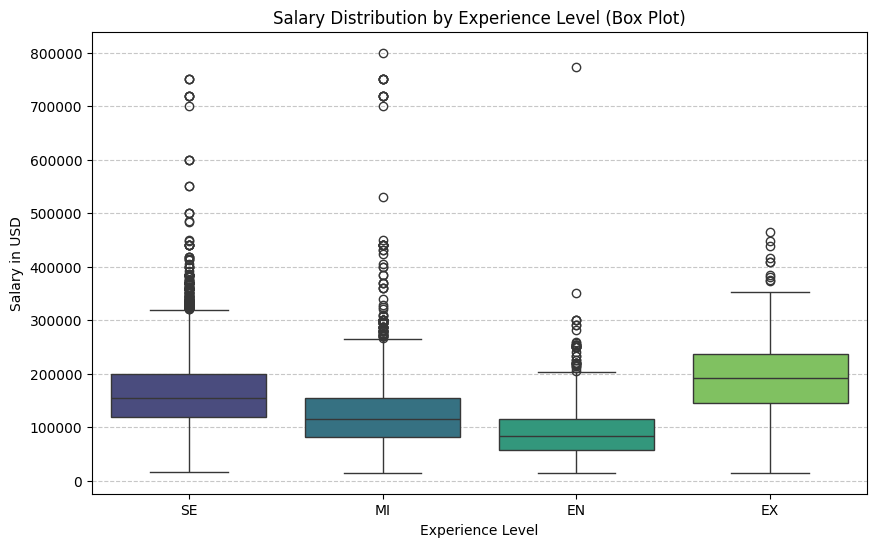

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df, palette='viridis')
plt.title('Salary Distribution by Experience Level (Box Plot)')
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

These results are as expected, with executives having the highest average salary, followed by seniors, then middle then entry.

However, what is interesting is that executives have a smaller range compared to senior and middle expericned workers, its not surprising that entry level roles dont have very much variation in the range of salary. However the one point in the entry level category with a salary of almost 800,000 USD represents a clear outlier, this could be due to an error or it could be a special case. With more time on this data set, this outlier would need to be investigated

These finding are important because it  impacts how I could interpret other salary distributions. For example, the  average salary for on-site roles was higher, but this could be because there are more senior people in on-site roles.

I will now use the AI prompt "create the heatmap showing the average salary for each combination of Experience Level vs. Remote Ratio"


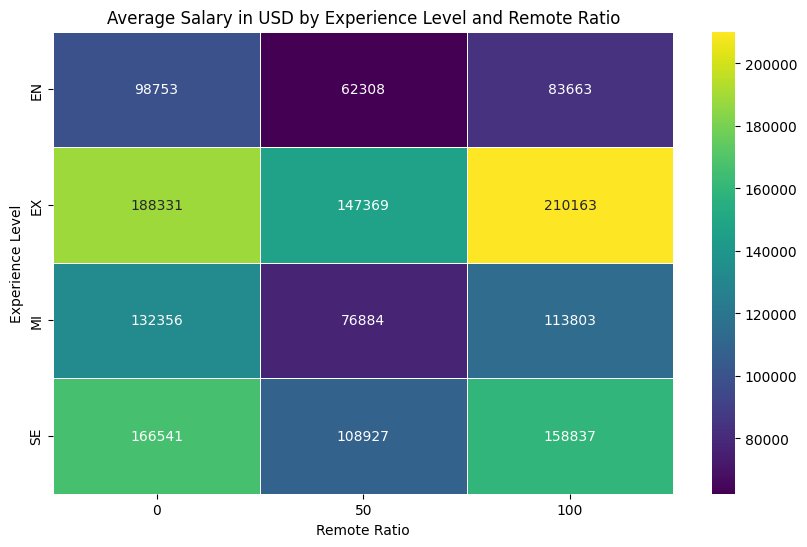

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average salary for each combination of experience_level and remote_ratio
avg_salary_pivot = df.groupby(['experience_level', 'remote_ratio'])['salary_in_usd'].mean().unstack()

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(avg_salary_pivot, annot=True, fmt='.0f', cmap='viridis', linewidths=.5)
plt.title('Average Salary in USD by Experience Level and Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Experience Level')
plt.show()

This heatmap clearly shows average salaries generally increase with experience. Interestingly, hybrid roles consistently pay the least across all levels. While on-site jobs typically offer more for entry, mid, and senior roles, for executive-level professionals, they actually earn the most, on average, in fully remote positions.

Lastly, I will use the AI prompt: visualize the distribution of 'salary_in_usd' across different 'employment_type' categories"


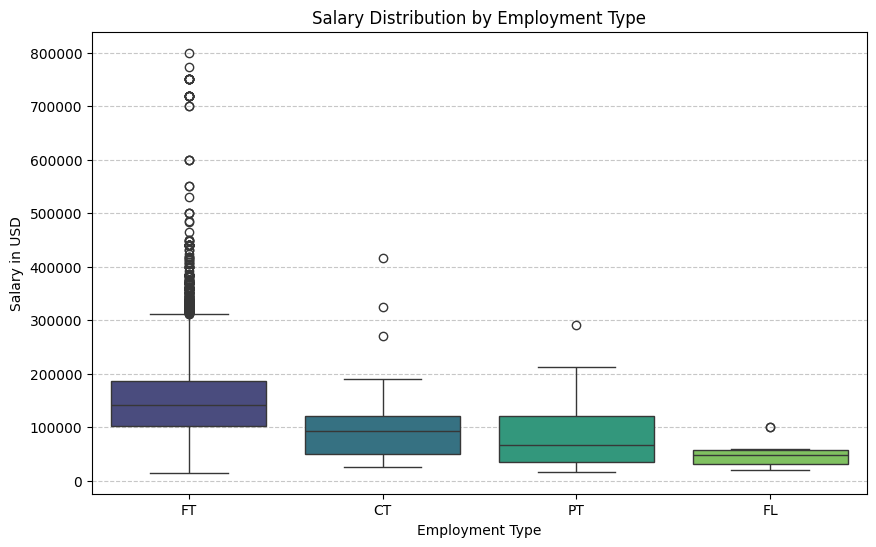

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='employment_type', y='salary_in_usd', data=df, palette='viridis', hue='employment_type', legend=False)
plt.title('Salary Distribution by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Salary in USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Full-time employment offers the highest median salary and broadest range, including top earners. Contract roles pay less than full-time but more than part-time, which has the lowest median. Freelance data points are limited, yet they seemingly have the lowest salaries overall.

Full time employment having the highest salaries makes sense as executives and senior managers (who have the highest salaries of the expericne levels), would likley work full time rather than on a contract, part time or via freelance. Frelance work having the lowest salaies also makes sense as frelance work typically reqires less expertise




---


I did not convert any of the categorical variables into numerical data at the start of the analysis, apon refelction, by doing this, it may allow me to draw more conclusions, as an example. I will convert the variable "Experience Level" into numerical data.

This variable has 4 categories:

EN (Entry Level)
MI (Middle)
SE (Senior)
EX (Executive)

Given that these levels of expericne are on a scale, i will allocate the following numerical values to each category to use ordinal Encoding with scaled values:

EN (Entry Level): 0.25
MI (Middle): 0.5
SE (Senior): 0.75
EX (Executive): 1

I will use the AI prompt: "Convert the experience_level column to numerical values: EN=0.25, MI=0.5, SE=0.75, EX=1.0. and display the first 5 rows of the DataFrame with the new column."


In [ ]:
experience_level_mapping = {
    'EN': 0.25,
    'MI': 0.5,
    'SE': 0.75,
    'EX': 1.0
}
df['experience_level_numeric'] = df['experience_level'].map(experience_level_mapping)
display(df.head())

KeyError: 'experience_level'

I now have a new column for experience_ level_numeric.
I will drop the experience_level column.

In [ ]:

df = df.drop(["experience_level"], axis=1)
df.head()


,work_year,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_numeric
0,2024,FT,AI Engineer,202730,USD,202730,US,0,US,M,0.75
1,2024,FT,AI Engineer,92118,USD,92118,US,0,US,M,0.75
2,2024,FT,Data Engineer,130500,USD,130500,US,0,US,M,0.75
3,2024,FT,Data Engineer,96000,USD,96000,US,0,US,M,0.75
4,2024,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M,0.75


If I had more time I would convert some of the over categorical variables too, some could be coveretd and some would need to use one-hot encoding.

By having expericne level as a numberical value, I can more easily calculate for example, the mean, to understand how much experience the data set has on avaerge. I can also create a scatter plot. I will use the AI prompt "create a scatter plot of avaerage salary  in USD and exericne level"


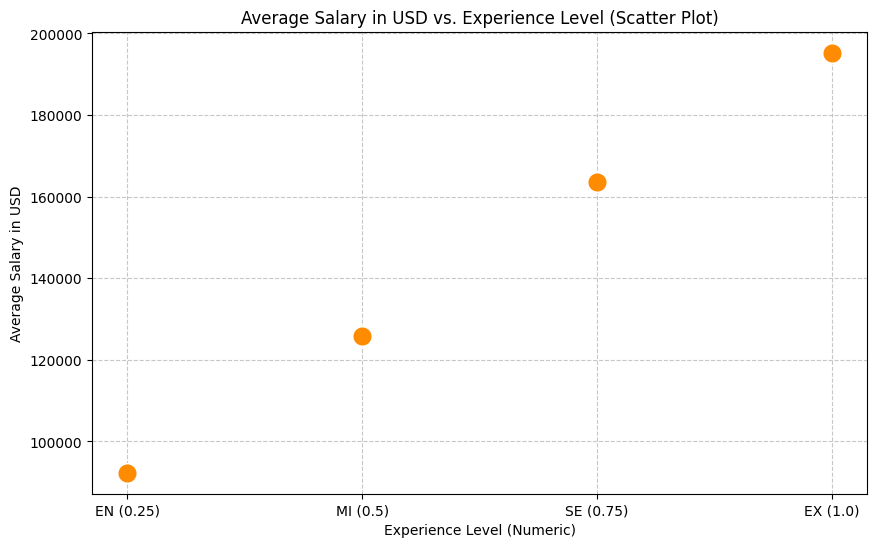

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure avg_salary_by_exp_level is available (recalculate if necessary)
avg_salary_by_exp_level = df.groupby('experience_level_numeric')['salary_in_usd'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='experience_level_numeric', y='salary_in_usd', data=avg_salary_by_exp_level, s=200, color='darkorange', zorder=2)
plt.title('Average Salary in USD vs. Experience Level (Scatter Plot)')
plt.xlabel('Experience Level (Numeric)')
plt.ylabel('Average Salary in USD')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=[0.25, 0.5, 0.75, 1.0], labels=['EN (0.25)', 'MI (0.5)', 'SE (0.75)', 'EX (1.0)']) # Custom ticks for clarity
plt.show()

This shows clearly that there is a positive linear relationship between expericne level and average salary in USD, this is to be expected.